# WEEK 6 - DATA 56000
## Assignment #6: TomoGAN for Scientific Image Denoising
**Pol Monne Parera (L30170743)**  
pmonneparera@lewisu.edu  
Spring 2026

Generative Adversarial Network (TomoGAN) for denoising real scientific images.

### 1. Imports

In [4]:
import os
import time
import shutil
from pathlib import Path
from urllib.request import urlretrieve

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    SKIMAGE_AVAILABLE = True
except Exception:
    SKIMAGE_AVAILABLE = False

np.random.seed(42)
tf.random.set_seed(42)

In [5]:
def _make_legacy_initializer_compatible(base_initializer):
    class LegacyCompatInitializer(base_initializer):
        @classmethod
        def from_config(cls, config):
            config = dict(config)
            config.pop('dtype', None)
            return cls(**config)
    LegacyCompatInitializer.__name__ = base_initializer.__name__
    return LegacyCompatInitializer

LEGACY_CUSTOM_OBJECTS = {
    name: _make_legacy_initializer_compatible(getattr(tf.keras.initializers, name))
    for name in [
        'GlorotUniform', 'Zeros', 'Ones', 'RandomNormal',
        'RandomUniform', 'TruncatedNormal', 'Orthogonal', 'Constant'
    ]
    if hasattr(tf.keras.initializers, name)
}

### 2. Download Dataset and Pre-trained Model

In [7]:
DATA_DIR = Path('dataset')
MODEL_DIR = Path('model')
OUTPUT_DIR = Path('outputs')

for directory in [DATA_DIR, MODEL_DIR, OUTPUT_DIR]:
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True, exist_ok=True)

DATASET_URL = 'https://raw.githubusercontent.com/AIScienceTutorial/Denoising/main/dataset/demo-dataset-real4test.h5'
MODEL_URL = 'https://raw.githubusercontent.com/AIScienceTutorial/Denoising/main/model/TomoGAN.h5'

dataset_path = DATA_DIR / 'demo-dataset-real4test.h5'
model_path = MODEL_DIR / 'TomoGAN.h5'

def download_if_needed(url, destination):
    if destination.exists():
        print(f'Already exists: {destination}')
    else:
        print(f'Downloading {destination.name} ...')
        urlretrieve(url, destination)
        print(f'Saved to: {destination}')

download_if_needed(DATASET_URL, dataset_path)
download_if_needed(MODEL_URL, model_path)

Saved to: dataset/demo-dataset-real4test.h5
Saved to: model/TomoGAN.h5


### 3. Load and Inspect the Scientific Image Dataset

In [9]:
with h5py.File(dataset_path, 'r') as h5fd:
    ns_img_test_real = h5fd['test_ns'][:]
    gt_img_test_real = h5fd['test_gt'][:]

print(f'Noisy test set shape: {ns_img_test_real.shape}')
print(f'Ground-truth test set shape: {gt_img_test_real.shape}')
print(f'Dtype: {ns_img_test_real.dtype}')
print(f'Noisy intensity range: [{ns_img_test_real.min():.3f}, {ns_img_test_real.max():.3f}]')
print(f'GT intensity range: [{gt_img_test_real.min():.3f}, {gt_img_test_real.max():.3f}]')

Noisy test set shape: (16, 1024, 1024)
Ground-truth test set shape: (16, 1024, 1024)
Dtype: uint8
Noisy intensity range: [0.000, 255.000]
GT intensity range: [0.000, 255.000]


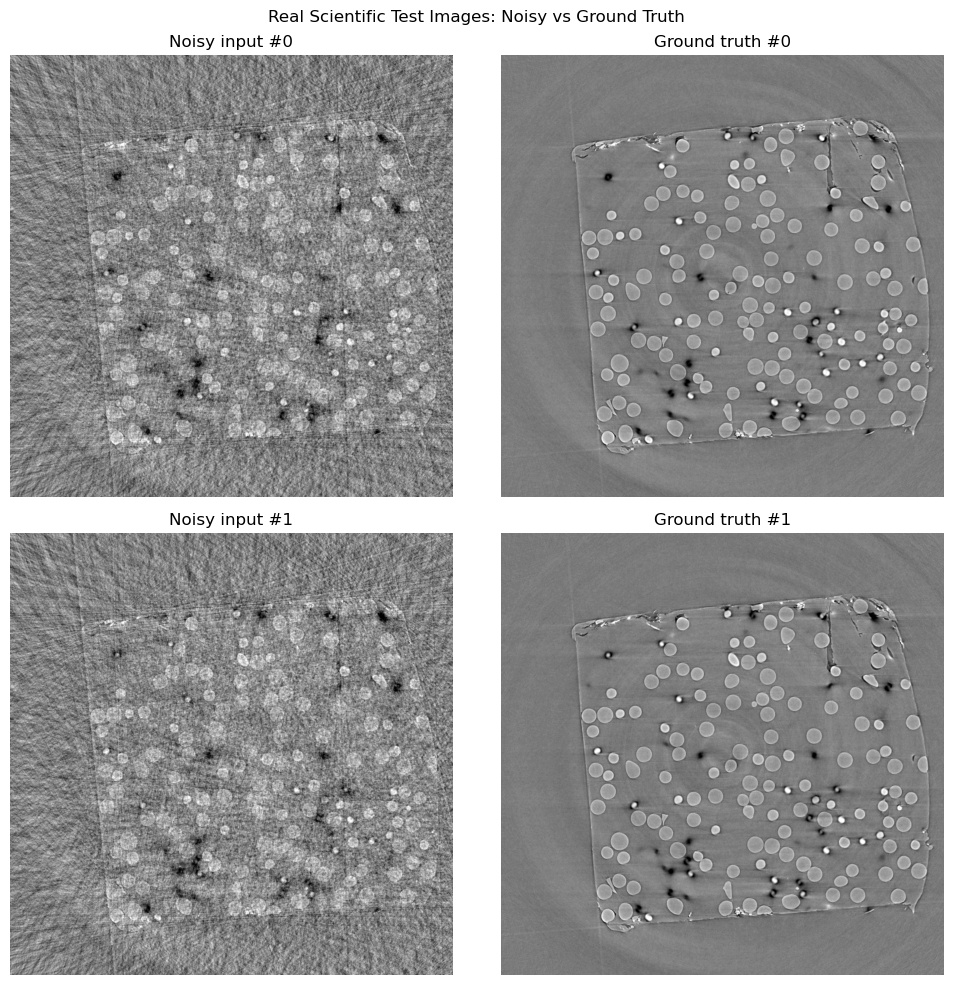

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    axes[i, 0].imshow(ns_img_test_real[i], cmap='gray')
    axes[i, 0].set_title(f'Noisy input #{i}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_img_test_real[i], cmap='gray')
    axes[i, 1].set_title(f'Ground truth #{i}')
    axes[i, 1].axis('off')

plt.suptitle('Real Scientific Test Images: Noisy vs Ground Truth', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'raw_vs_gt_examples.png', dpi=140, bbox_inches='tight')
plt.show()

### 4. Load the Pre-trained TomoGAN Model

In [12]:
TomoGAN_mdl = tf.keras.models.load_model(
    model_path,
    custom_objects=LEGACY_CUSTOM_OBJECTS,
    compile=False,
)
TomoGAN_mdl.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │         16 │ input_1[0][0]     │
│                     │ None, 8)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      2,336 │ conv2d[0][0]      │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      9,248 │ conv2d_1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_3[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     73,856 │ max_pooling2d_1[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │    147,584 │ conv2d_5[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, None,      │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │    147,584 │ max_pooling2d_2[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, None,      │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ None, 256)        │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │    147,520 │ concatenate[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_8[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, None,      │          0 │ conv2d_9[0][0]  

 Total params: 694,897 (2.65 MB)

 Trainable params: 694,897 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Denoise the Test Images

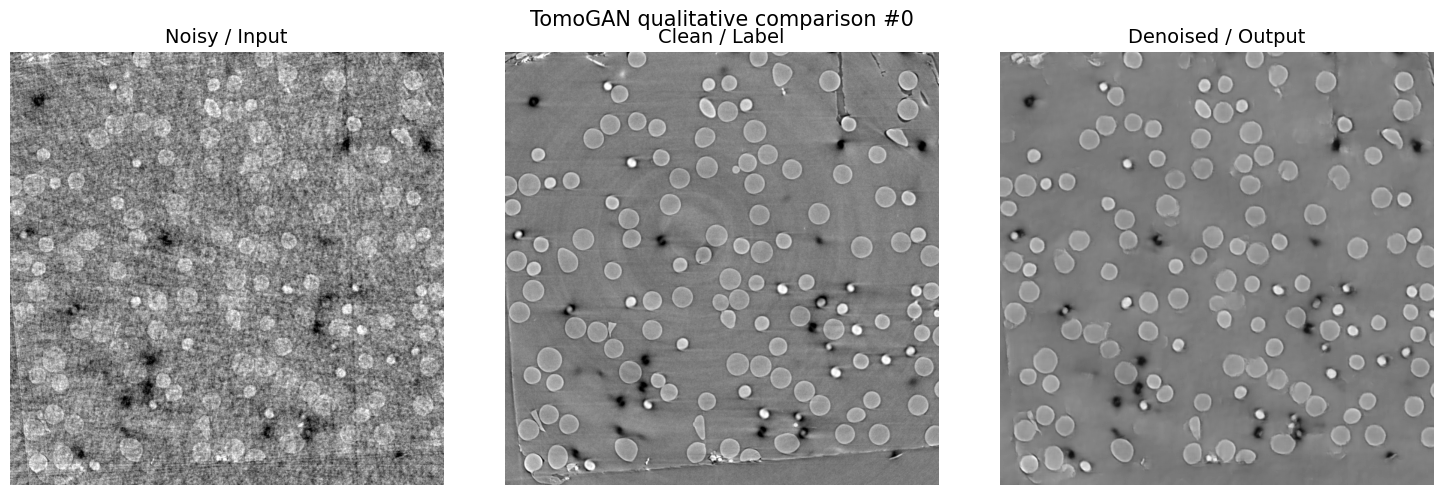

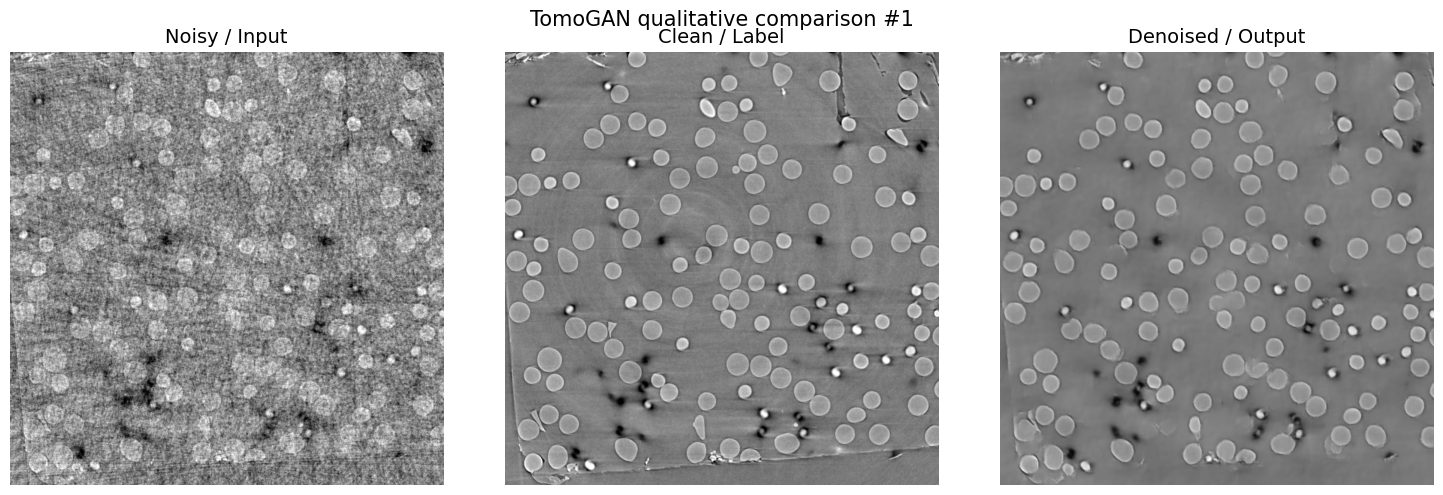

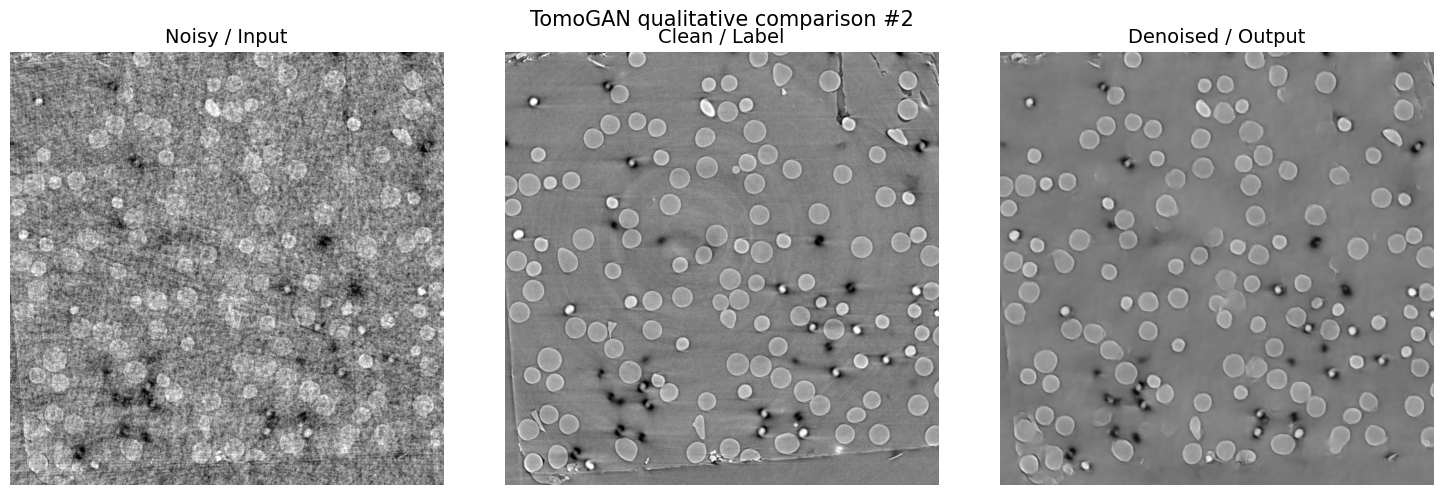

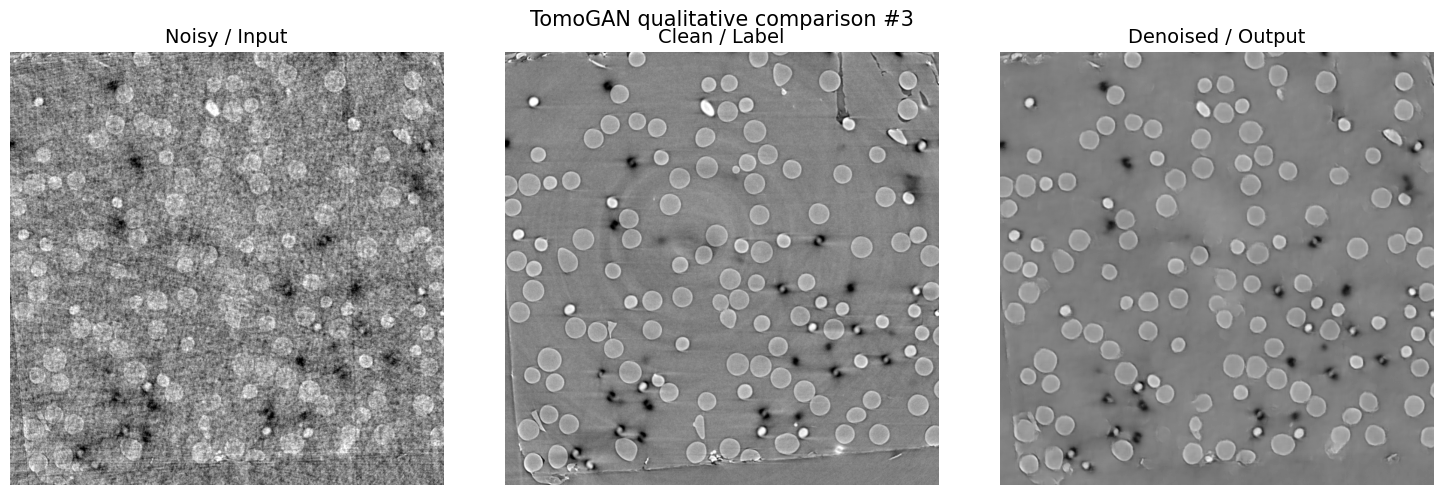

Saved 4 qualitative comparison figures to /Users/polmonneparera/Desktop/GI_25_26_Master/Asignatures/Lewis/NN&DL/Week 6/outputs


In [14]:
def show_triplet(noisy_img, clean_img, denoised_img, index, crop=(200, -100, 200, -100)):
    top, bottom, left, right = crop
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(noisy_img[top:bottom, left:right], cmap='gray')
    axes[0].set_title('Noisy / Input', fontsize=14)
    axes[1].imshow(clean_img[top:bottom, left:right], cmap='gray')
    axes[1].set_title('Clean / Label', fontsize=14)
    axes[2].imshow(denoised_img[top:bottom, left:right], cmap='gray')
    axes[2].set_title('Denoised / Output', fontsize=14)
    for ax in axes:
        ax.axis('off')
    plt.suptitle(f'TomoGAN qualitative comparison #{index}', fontsize=15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'tomogan_triplet_{index}.png', dpi=140, bbox_inches='tight')
    plt.show()

denoised_examples = []
for idx in range(min(4, ns_img_test_real.shape[0])):
    denoised_img = TomoGAN_mdl.predict(ns_img_test_real[idx:idx+1, :, :, np.newaxis], verbose=0).squeeze()
    denoised_examples.append(denoised_img)
    show_triplet(ns_img_test_real[idx], gt_img_test_real[idx], denoised_img, idx)
print(f'Saved {len(denoised_examples)} qualitative comparison figures to {OUTPUT_DIR.resolve()}')

### 6. Batch Inference Timing

In [16]:
batch_sz = len(ns_img_test_real)
tick = time.time()
batch_denoised = TomoGAN_mdl.predict(
    ns_img_test_real[:batch_sz, :, :, np.newaxis],
    verbose=0
).squeeze()
elapsed = time.time() - tick

print(f'Batch size: {batch_sz}')
print(f'Image size: {ns_img_test_real.shape[1]} x {ns_img_test_real.shape[2]}')
print(f'Total inference time: {elapsed:.2f} seconds')
print(f'Average time per image: {elapsed / batch_sz:.2f} seconds')
print(f'Batch output shape: {batch_denoised.shape}')

Batch size: 16
Image size: 1024 x 1024
Total inference time: 13.72 seconds
Average time per image: 0.86 seconds
Batch output shape: (16, 1024, 1024)


### 7. Quantitative Metrics

In [18]:
metric_rows = []

for idx in range(batch_sz):
    noisy = ns_img_test_real[idx].astype(np.float32)
    clean = gt_img_test_real[idx].astype(np.float32)
    denoised = batch_denoised[idx].astype(np.float32)

    data_range = float(clean.max() - clean.min())
    if data_range == 0:
        data_range = 1.0

    row = {
        "Sample": idx,
        "MSE noisy->gt": np.mean((noisy - clean) ** 2),
        "MSE denoised->gt": np.mean((denoised - clean) ** 2),
        "MAE noisy->gt": np.mean(np.abs(noisy - clean)),
        "MAE denoised->gt": np.mean(np.abs(denoised - clean)),
        "PSNR noisy->gt": peak_signal_noise_ratio(clean, noisy, data_range=data_range),
        "PSNR denoised->gt": peak_signal_noise_ratio(clean, denoised, data_range=data_range),
        "SSIM noisy->gt": structural_similarity(clean, noisy, data_range=data_range),
        "SSIM denoised->gt": structural_similarity(clean, denoised, data_range=data_range),
    }

    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))

print("Average metrics:")
display(metrics_df.drop(columns=["Sample"]).mean().to_frame("Mean").T.round(4))

,Sample,MSE noisy->gt,MSE denoised->gt,MAE noisy->gt,MAE denoised->gt,PSNR noisy->gt,PSNR denoised->gt,SSIM noisy->gt,SSIM denoised->gt
0,0,777.936401,171.402802,22.229000,8.0770,19.2214,25.7906,0.2113,0.6646
1,1,802.185974,188.836700,22.590700,8.8281,19.0881,25.3699,0.2113,0.6609
2,2,746.184570,172.453400,21.746700,7.9435,19.4023,25.7641,0.2136,0.6586
3,3,730.086487,176.083099,21.487499,8.2156,19.4971,25.6736,0.2133,0.6598
4,4,714.780518,178.515900,21.250999,8.0869,19.5891,25.6140,0.2194,0.6518
5,5,687.850586,178.651093,20.910601,8.2983,19.7559,25.6107,0.2299,0.6533
6,6,625.393372,177.928207,19.941000,8.2450,20.1693,25.6284,0.2426,0.6461
7,7,643.718018,179.112106,20.190201,8.4504,20.0438,25.5996,0.2280,0.6621
8,8,583.597412,168.697998,19.228201,8.3674,20.4697,25.8597,0.2370,0.6783
9,9,567.296082,244.777603,18.912399,12.1228,20.5927,24.2431,0.2484,0.6855


Average metrics:


,MSE noisy->gt,MSE denoised->gt,MAE noisy->gt,MAE denoised->gt,PSNR noisy->gt,PSNR denoised->gt,SSIM noisy->gt,SSIM denoised->gt
Mean,692.266,192.1043,20.9086,9.1176,19.7553,25.3236,0.2238,0.661


### 8. Summary Comparison

In [20]:
improvement_summary = pd.DataFrame({
    "Metric": ["MSE", "MAE", "PSNR", "SSIM"],
    "Noisy Mean": [
        metrics_df["MSE noisy->gt"].mean(),
        metrics_df["MAE noisy->gt"].mean(),
        metrics_df["PSNR noisy->gt"].mean(),
        metrics_df["SSIM noisy->gt"].mean(),
    ],
    "Denoised Mean": [
        metrics_df["MSE denoised->gt"].mean(),
        metrics_df["MAE denoised->gt"].mean(),
        metrics_df["PSNR denoised->gt"].mean(),
        metrics_df["SSIM denoised->gt"].mean(),
    ]
})

display(improvement_summary.round(4))

,Metric,Noisy Mean,Denoised Mean
0,MSE,692.2660,192.1043
1,MAE,20.9086,9.1176
2,PSNR,19.7553,25.3236
3,SSIM,0.2238,0.6610
